# Introduction
The primary objective of this lab is to familiarise you with the basic mechanics that allow you to get hold of satellite data for the purposes of carrying out machine learning. The second objective is for you to put into practice some of the theory that we covered in lectures 1 and 2, in order that you can start to understand some of the specific quirks and potentially powerful attributes of satellite data when it comes to applying machine learning techniques.

This lab has drawn upon the following sources, tutorials and repos:


*   https://geemap.org/
*   https://developers.google.com/earth-engine

Whenever you see a numbered question, e.g. '(1)', make sure that you answer it in the answer proforma and submit the resulting document on Canvas. Only submit in .docx or .pdf formats (we cannot open 'pages' etc docs on Canvas).

If you want to submit code as your 'working' OR we ask you to give your code as part of the answer, give a link in your proforma document to a Colab notebook that is stored in a place we can access (your own GitHub account for example!).

Some of the questions will be relatively simple and are designed to get you thinking about the nature of the code and what it is doing, whilst also requiring you to pull in theoretical knowledge from the lectures. Other questions are exercises that ask you to both apply this knowledege to a new challenge and/or require you to independently go and seek answers.

In all cases I encourage you to give it a go, even if you do not have the full answer. Particularly for the larger challenges ('Exercises'), marks are awarded for workings and I want to see your thought process in action via the code you write.

Use text comments as demonstrated in these lab instructions to explain your thinking and communicate with the person marking your work.

I use both comments above chunks of code to tell you the overall objectives of that code, and inline comments to highlight specific features and elements to be aware of (formatted like this to draw your attention '#<-').

You are expected to present outputs to a professional standard. This means maps must have scales, north arrows and legends that are readable. For a good guide to all matters professional figure drawing, see this Nature guide:
*    https://research-figure-guide.nature.com/figures/preparing-figures-our-specifications/.

A portion of the marks are for presentation and communication.

# Set up

In [2]:
# Set up GEE API
import ee
ee.Authenticate()
ee.Initialize(project='graphite-flare-503609-i6')

In [3]:
# Install the geemap package (only needs to be run once, uncomment below and run it the first time you run this notebook in a session).
# !pip install geemap

In [4]:
import geemap
for key in geemap.basemaps.keys():
  if "topo" in key.lower():
    print(key)


Esri.WorldTopoMap
OpenTopoMap
USGS.USImageryTopo
USGS.USTopo


# Loading a map and displaying satellite data

In [5]:
# Use the built in functions to load an ipyleaflet basemap (this is a UI to explore and see what we are doing)
# Note that I used to show you Open Street Map here, but there is currently a tile/scraper battle going on, and notebooks have been caught in the cross-fire.
Map = geemap.Map(center=(-41, 172), zoom=4, basemap="HYBRID")
Map

Map(center=[-41, 172], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tr…

In [6]:
# Specify a different kind of basemap to display data layers over
Map = geemap.Map(center=(-41, 172), zoom=4) #<- note the lat-lon coordinate pair here
Map.add_basemap("USGS.USImageryTopo")
Map

Map(center=[-41, 172], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tr…

# Question 1

(1) Find and add the basemap 'OpenTopoMap' to the display window AND change the code so that the map opens and zooms to the city of Auckland.
Provide a link to your code in a notebook and the output as a figure in the answer proforma. (2 pts)

In [7]:
# Add Earth Engine datasets to our map by first creating variables to hold the calls to the EE api
# Center our map to Auckland.
Map_q1 = geemap.Map(center=(-36.8485, 174.7633), zoom=12, height="900px")
dem = ee.Image("USGS/SRTMGL1_003")
landcover = ee.Image("ESA/GLOBCOVER_L4_200901_200912_V2_3").select("landcover")
landsat7 = ee.Image("LANDSAT/LE7_TOA_5YEAR/1999_2003")
states = ee.FeatureCollection("TIGER/2018/States")

In [8]:
# Set visualization parameters.
vis_params = {
    "min": 0,
    "max": 4000, #<- if your satellite image is all white or all black, these vis params are the first thing to check and change
    "palette": ["006633", "E5FFCC", "662A00", "D8D8D8", "F5F5F5"], #<- these are HTML colour codes
}

In [9]:
# Add a variety of different Earth Engine layers to the Map object
Map_q1.addLayer(dem, vis_params, "SRTM DEM", True, 0.6) #<- note vis params called from the dictionary we set up before
Map_q1.addLayer(landcover, {}, "Land cover")
Map_q1.addLayer(
    landsat7, {"bands": ["B4", "B3", "B2"], "min": 20, "max": 200}, "Landsat 7" #<- note vis params in a dictionary here inside the add layer call
)
Map_q1.addLayer(states, {}, "US States")

In [10]:
# Add the topological Basemap
Map_q1.add_basemap("OpenTopoMap")

In [11]:
# Dump all of this into the map view and take a look...
# Scroll around (look at both NZ and USA), check and uncheck the layers in the layer menu on the top-right.
Map_q1


Map(center=[-36.8485, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

In [12]:
import mapfig 
try:
    import mapfig  #<- this is a AI-generated package made to help me make figures from maps. Not important for reproduction -> figure can be seen in proforma.
    HAVE_MAPFIG = True
except ImportError:
    HAVE_MAPFIG = False
    print("mapfig.py not found — skipping figure regeneration. "
          "Clone Lab-Notebooks/Lab1/ to re-run this cell.")
if HAVE_MAPFIG:
    report = mapfig.figure_from_tiles(
        center       = (-36.8485, 174.7633),
        zoom         = 12,
        out_stem     = "fig1_auckland",
        size_px      = (1250, 950),
        hidpi        = False,      # <- labels stay legible
    fig_width_mm = 183,        # <- full text width
    bar_km       = 10,
    panel        = "a",
    graticule    = True,
    )
    report

(2) The Landsat 7 data displays as red colored/tinged image. Why is this? [Think about both the content in Lecture 1, and what is going on when you visualize a satellite image]. (2 pts)

# Question 3

(3) Correct the display of the Landsat 7 image so that it displays in '[True Colour](https://weather.ndc.nasa.gov/sport/training/quickGuides/rgb/QuickGuide_TrueColorRGB_NASA_SPoRT.pdf)'. Provide a notebook example of your code and the corrected output over the whole of New Zealand. (10 pts)

In [13]:
Map3 = geemap.Map(center=(-41.0, 173.0), zoom=6, height="900px")

landsat7 = ee.Image("LANDSAT/LE7_TOA_5YEAR/1999_2003")

vis_params = {
    'bands': ['B3','B2','B1'],  # Red, Green, Blue
    'min': 0,
    'max': 128,
    'gamma': 1.4 # adjusts contrast, 1.0 is no change, <1.0 is more contrast, >1.0 is less contrast
}

Map3.addLayer(
    landsat7,
    vis_params,
    "Landsat 7"
)
Map3

Map(center=[-41.0, 173.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

# Spectral reflectance curves
Next we we will generate a spectral reflectance curve for a given area.
This is a useful tool when you are considering if a given target has spectral characteristics for identification in ML. If everything has the same spectral signature, then you need to take a different approach to a simple spectral classification, as might have been the first instinct of a classical remote sensing scientist before the advent of machine learning.

In [14]:
# Add in a library for plotting the data we extract
import matplotlib.pyplot as plt

In [15]:
# Define a point and a small rectangular region around it
point = ee.Geometry.Point([174.7633, -36.8485])  # Auckland, NZ
region = point.buffer(150).bounds()  # ~300 m box

In [16]:
# Load a Landsat 7 Collection 2 Level 2 SR image (surface reflectance)
image = ee.ImageCollection('LANDSAT/LE07/C02/T1_L2') \
    .filterBounds(region) \
    .filterDate('2002-01-01', '2002-12-31') \
    .sort('CLOUD_COVER') \
    .first()

(4) Why are we using the surface reflectance (SR) here rather than the top of atmosphere (ToA)? (2 pt)

In [17]:
# Select surface reflectance bands and apply scale factor
bands = ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7']
band_names = {
    'SR_B1': 'Blue (0.45–0.52 μm)',
    'SR_B2': 'Green (0.52–0.60 μm)',
    'SR_B3': 'Red (0.63–0.69 μm)',
    'SR_B4': 'NIR (0.77–0.90 μm)',
    'SR_B5': 'SWIR1 (1.55–1.75 μm)',
    'SR_B7': 'SWIR2 (2.09–2.35 μm)'
}

scale_factor = 2.75e-5  # From USGS documentation for Landsat C2 L2

(5) What is a 'scale factor' as has been used in the prior code cell, and why are they used in satellite data storage-to-processing workflows such as this? (2 pts)

**Important sidenote**

The 'reduce' operation is a key concept in the backend of how Google is storing and serving us large quanities of satellite data. GEE uses 'reducers' in multiple ways, many of which are not always immediately intuitive. Check out the docs for more information:

*   https://developers.google.com/earth-engine/guides/reducers_intro

Here we are using a reduce operation over the specified small sample area in order to find the mean of all the cells that lie within the region:

In [18]:
# Reduce region to mean reflectance
mean_dict = image.select(bands).reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=region,
    scale=30,
    maxPixels=1e6
)

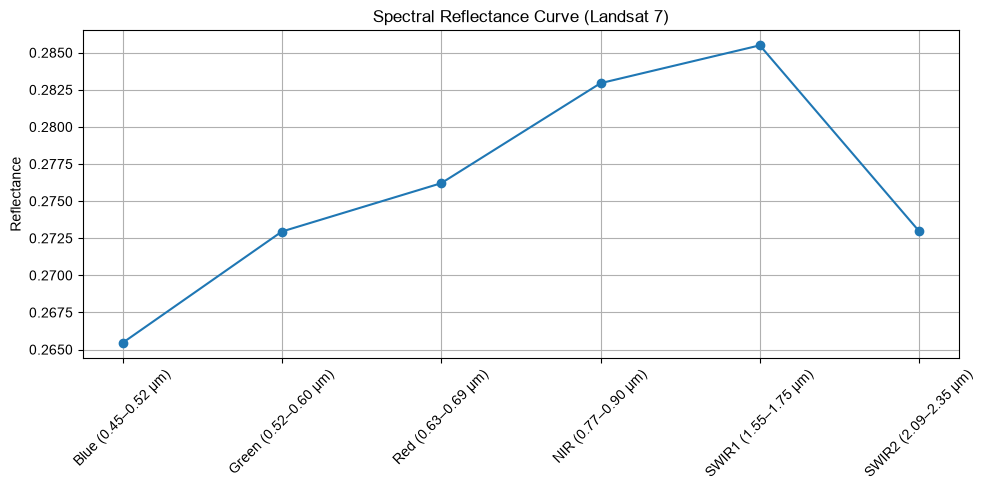

In [19]:
# Extract and scale values
mean_values = mean_dict.getInfo()
reflectance = [mean_values[b] * scale_factor for b in bands]

# Plot the spectral curve
plt.figure(figsize=(10, 5))
plt.plot(list(band_names.values()), reflectance, marker='o', linestyle='-')
plt.title('Spectral Reflectance Curve (Landsat 7)')
plt.ylabel('Reflectance')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

(6) If we want to apply multiple reducers to the same inputs what is a more efficient way to do so than just writing out a long series of sequential reducers on our end? (2 pts)

# Cloud cover
A final consideration that I want to cover in this lab is that of cloud cover. Cloud cover removal is a complex and often difficut process that GISCI 341 students spend an entire two weeks tackling as a focus (so use them in your teams!). However, for our purpose here lets just use the basic in-built cloud clearing native to the Landsat 7 collection on GEE.

In [20]:
# Define small region around Auckland, NZ
point = ee.Geometry.Point([174.7633, -36.8485])
region = point.buffer(500).bounds()

# Load the image with least cloud cover in 2002
image = ee.ImageCollection("LANDSAT/LE07/C02/T1_L2") \
    .filterBounds(region) \
    .filterDate("2002-01-01", "2002-12-31") \
    .sort("CLOUD_COVER") \
    .first() #<- note the filtering step that is being applied here! We are taking the first image in a sorted by cloud cover response.

# Check metadata
print('Image ID:', image.get('LANDSAT_PRODUCT_ID').getInfo())
print('Cloud Cover (whole scene):', image.get('CLOUD_COVER').getInfo())

Image ID: LE07_L2SP_073086_20020827_20200916_02_T1
Cloud Cover (whole scene): 1


In [21]:
# Function to mask clouds using QA_PIXEL band
def mask_clouds(image):
    qa = image.select('QA_PIXEL')
    # Bits 3 and 4 are cloud and cloud shadow respectively
    cloud_mask = qa.bitwiseAnd(1 << 3).eq(0).And(
                 qa.bitwiseAnd(1 << 4).eq(0))
    return image.updateMask(cloud_mask)

# Apply mask
masked_image = mask_clouds(image)

**Important side note**

In the function above we are using a bitwise operation in order to search through the quality assurance (QA) band of the image. Different satellites have different bit-masks. Read more about bitmasks and how they are used here:
*   https://spatialthoughts.com/2021/08/19/qa-bands-bitmasks-gee/



**Another important side note**

You will have noticed that we are frequently running code and not seeing anything happen in terms of output in the cell or changes in the RAM/Disk of the Colab instance (check the small graphs top right). This is deliberate! Satellite data is large and hard to wrangle. GEE does a lot of the work for us, hence we can explore and get into it so quickly. Part of how it does this is by not executing any of your API calls until you specifically ask for an output to be sent back to you. Prior to calling an output (usually through a 'AddLayer' or similar call), when using the GEE/EE API you are essentially chaining together a lot of dot-operators (e.g. '.sort \ .reduce') into a series of instructions that are verified, but only then acted on when required.

This is the result of a 'client vs. server' approach. For more detail, that will help you understand why you can and cannot do certain things, see:
*   https://developers.google.com/earth-engine/guides/client_server



In [22]:
# Report Image Quality Over ROI
# Total pixels in region
pixel_area = ee.Image.pixelArea().clip(region)

# Count valid pixels before and after masking
total_pixels = pixel_area.reduceRegion(
    reducer=ee.Reducer.count(),
    geometry=region,
    scale=30,
    maxPixels=1e9
).getInfo()['area']

valid_pixels = masked_image.select('SR_B3').reduceRegion(
    reducer=ee.Reducer.count(),
    geometry=region,
    scale=30,
    maxPixels=1e9
).getInfo()['SR_B3']

cloud_coverage_pct = 100 * (1 - valid_pixels / total_pixels)

print(f"Total Pixels: {total_pixels}")
print(f"Valid (non-cloud) Pixels: {valid_pixels}")
print(f"Estimated Cloud Coverage in ROI: {cloud_coverage_pct:.2f}%")

Total Pixels: 1394
Valid (non-cloud) Pixels: 1050
Estimated Cloud Coverage in ROI: 24.68%


In [23]:
# Visualize the before and after
Map = geemap.Map(center=[-36.8485, 174.7633], zoom=12)

vis = {
    'bands': ['SR_B3', 'SR_B2', 'SR_B1'],
    'min': 0,
    'max': 30000,
    'gamma': 1.4
}

Map.addLayer(image, vis, 'Original Image (Cloudy)')
Map.addLayer(masked_image, vis, 'Cloud Masked')
Map

Map(center=[-36.8485, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

# Question 7

(7) Produce a table that tells me the average amount of cloud cover per LandSat image in a year: for 2005, 2010 and 2015. Do this over a region of your choice, as a percentage.

Provide a notebook example of your code that does so, in addition to your table. (5 pts)

In [24]:
## Note: generated with AI assistance (Claude, Anthropic, 12 Aug 2026).
## Reviewed, tested and verified by the author, who is responsible for the output.

# Average cloud cover per Landsat 7 image, by year: 2005, 2010, 2015
#
# Region of choice: the same small Auckland ROI used in the cloud cover section above.
# "Cloud cover" here is the percentage of the ROI's *data-carrying* pixels flagged as
# cloud/cloud-shadow by the QA_PIXEL band (via mask_clouds, defined earlier), rather
# than the whole-scene CLOUD_COVER metadata field (which describes the full Landsat
# scene, not just our small ROI).
#
# Important: all three years are after the Scan Line Corrector failure of 31 May 2003,
# so every Landsat 7 image carries wedge-shaped data gaps. Those gap pixels are NoData
# and would otherwise be counted as cloud. We therefore measure cloud as a fraction of
# the pixels that actually carry data, and report the gap fraction separately.

import pandas as pd

point = ee.Geometry.Point([174.7633, -36.8485])  # Auckland, NZ
region = point.buffer(500).bounds()

REDUCE_KWARGS = dict(reducer=ee.Reducer.count(), geometry=region,
                     scale=30, maxPixels=1e9)

# Total number of pixels in the ROI at 30 m resolution (pixelArea is never masked)
total_pixels = ee.Number(
    ee.Image.pixelArea().clip(region).reduceRegion(**REDUCE_KWARGS).get("area")
)


def add_cloud_pct(image):
    """Attach gap %, cloud % and a usable-pixel count to an image."""
    # Pixels with data at all: excludes SLC-off gaps and any area outside the footprint
    with_data = ee.Number(
        image.select("SR_B3").reduceRegion(**REDUCE_KWARGS).get("SR_B3")
    )
    # Pixels surviving the QA_PIXEL cloud/shadow mask
    cloud_free = ee.Number(
        mask_clouds(image).select("SR_B3").reduceRegion(**REDUCE_KWARGS).get("SR_B3")
    )

    gap_pct = ee.Number(1).subtract(with_data.divide(total_pixels)).multiply(100)
    # max(with_data, 1) guards the division; images with 0 are filtered out below
    cloud_pct = (
        ee.Number(1)
        .subtract(cloud_free.divide(with_data.max(1)))
        .multiply(100)
    )

    return image.set({
        "valid_px": with_data,
        "gap_pct": gap_pct,
        "cloud_pct": cloud_pct,
    })


years = [2005, 2010, 2015]
rows = []

for year in years:
    collection = (
        ee.ImageCollection("LANDSAT/LE07/C02/T1_L2")
        .filterBounds(region)
        .filterDate(f"{year}-01-01", f"{year + 1}-01-01")
        .map(add_cloud_pct)
    )

    n_total = collection.size().getInfo()

    # Drop images where the ROI falls entirely within an SLC-off gap or outside
    # the scene footprint: these carry no information about cloud.
    usable = collection.filter(ee.Filter.gt("valid_px", 0))
    n_usable = usable.size().getInfo()

    if n_usable == 0:
        rows.append({"Year": year, "Images (n)": n_total, "Usable (n)": 0,
                     "Mean data gaps (%)": None, "Mean cloud cover (%)": None})
        continue

    stats = usable.reduceColumns(
        reducer=ee.Reducer.mean().repeat(2),
        selectors=["gap_pct", "cloud_pct"],
    ).getInfo()["mean"]

    rows.append({
        "Year": year,
        "Images (n)": n_usable,
        "Mean cloud cover (%)": round(stats[1], 1),
    })

cloud_cover_table = pd.DataFrame(rows)
cloud_cover_table

,Year,Images (n),Mean cloud cover (%)
0,2005,55,54.1
1,2010,59,64.9
2,2015,60,58.7


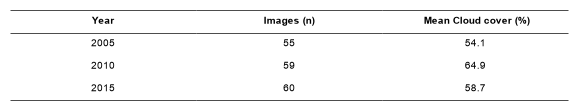

In [25]:
## Note: The following code block is generated by AI to create a publication-ready table of the cloud cover data. 
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

MM = 1 / 25.4
fig, ax = plt.subplots(figsize=(183 * MM, 24 * MM))  # 89 mm = single column
ax.axis("off")

df = cloud_cover_table.copy()
col_labels = ["Year", "Images (n)", " Mean Cloud cover (%)"]
cell_text = [
    [str(int(r["Year"])), str(int(r["Images (n)"])), f'{r["Mean cloud cover (%)"]:.1f}']
    for _, r in cloud_cover_table.iterrows()
]

tbl = ax.table(cellText=cell_text, colLabels=col_labels,
               cellLoc="center", loc="center", edges="")
tbl.auto_set_font_size(False)
tbl.set_fontsize(7)
tbl.scale(1, 1.35)

n_rows = len(cell_text)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_text_props(weight="bold")
        cell.visible_edges = "BT"
        cell.set_linewidth(0.5)
    elif r == n_rows:
        cell.visible_edges = "B"
        cell.set_linewidth(0.5)

fig.savefig("cloud_cover_table.pdf", bbox_inches="tight")
plt.show()

# Final exercise
Let us now be very fancy and plot our spectral reflectance curve along with a display of the satellite data that it was generated from. As well as being fancy, this lets us see that what we have done here is sample the urban fabric of downtown Auckland and collect the spectral signature of 'urban'.

The code block below is large and calls in some further packages as we start to push beyond what is already built into geemap. I have also placed all the required code in one cell as I am about to ask you to do something with it... Make sure that you take the time understand what each section is doing and why. Consider starting to break this code down into functions that you can re-use later. If you do not know what I mean by this, please ask! (And Google 'modular code design, functions').

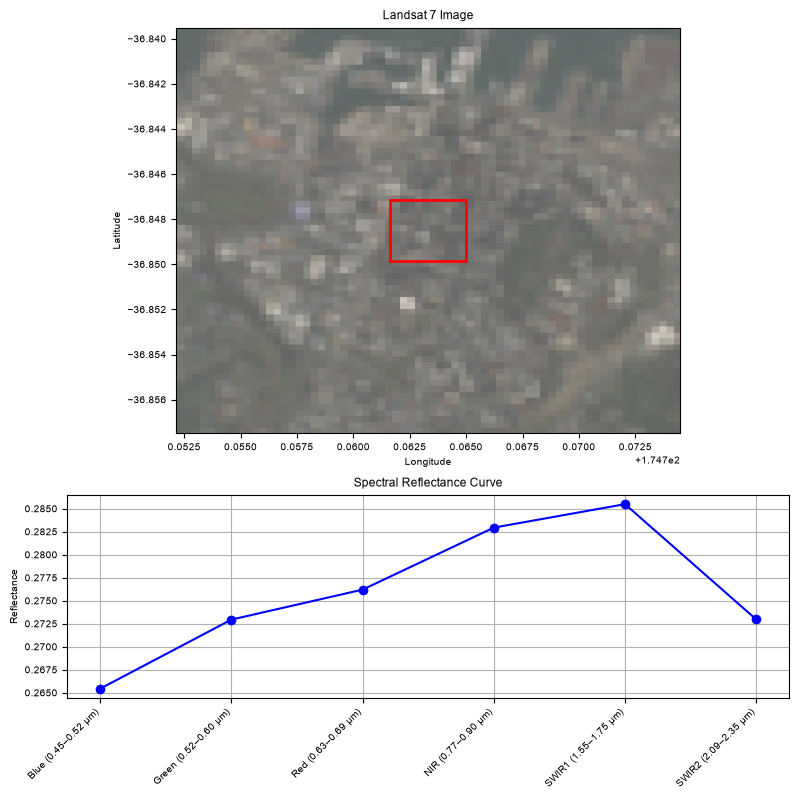

In [31]:
# Additional required packages
import matplotlib.patches as patches
import urllib.request
import tempfile
import matplotlib.image as mpimg
import numpy as np

# Define point and regions
point = ee.Geometry.Point([174.7633, -36.8485])
region = point.buffer(150).bounds()        # ~300 m box
expanded_region = point.buffer(1000).bounds()  # box for image preview

# Load Landsat 7 surface reflectance image
image = ee.ImageCollection('LANDSAT/LE07/C02/T1_L2') \
    .filterBounds(region) \
    .filterDate('2002-01-01', '2002-12-31') \
    .sort('CLOUD_COVER') \
    .first()

# Define bands and scaling
bands = ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7']
band_names = {
    'SR_B1': 'Blue (0.45–0.52 μm)',
    'SR_B2': 'Green (0.52–0.60 μm)',
    'SR_B3': 'Red (0.63–0.69 μm)',
    'SR_B4': 'NIR (0.77–0.90 μm)',
    'SR_B5': 'SWIR1 (1.55–1.75 μm)',
    'SR_B7': 'SWIR2 (2.09–2.35 μm)'
}
scale_factor = 2.75e-5

# Calculate mean reflectance
mean_dict = image.select(bands).reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=region,
    scale=30,
    maxPixels=1e6).getInfo()

reflectance = [mean_dict[b] * scale_factor for b in bands]
labels = list(band_names.values())

# Get RGB thumbnail slightly zoomed out
thumb_params = {
    'dimensions': 512,
    'region': expanded_region,
    'format': 'png',
    'bands': ['SR_B3', 'SR_B2', 'SR_B1'],
    'min': 0,
    'max': 30000,
    'gamma': 1.4
}
url = image.getThumbURL(thumb_params)

# Get coordinates of regions
def get_bounds_coords(bounds):
    coords = bounds.coordinates().getInfo()[0]
    lons = [pt[0] for pt in coords]
    lats = [pt[1] for pt in coords]
    return min(lons), max(lons), min(lats), max(lats)

# Extract bounding boxes
xmin, xmax, ymin, ymax = get_bounds_coords(expanded_region)
rxmin, rxmax, rymin, rymax = get_bounds_coords(region)

# Plot both panels
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), gridspec_kw={'height_ratios': [2, 1]})

img = np.array(Image.open(io.BytesIO(requests.get(url).content)))

ax1.imshow(img, extent=[xmin, xmax, ymin, ymax])
ax1.set_title("Landsat 7 Image")
ax1.set_xlim(xmin, xmax)
ax1.set_ylim(ymin, ymax)

width  = rxmax - rxmin
height = rymax - rymin
rect = patches.Rectangle((rxmin, rymin), width, height,
                         linewidth=2, edgecolor='red', facecolor='none')
ax1.add_patch(rect)
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
# Plot reflectance
ax2.plot(labels, reflectance, marker='o', color='blue')
ax2.set_title("Spectral Reflectance Curve")
ax2.set_ylabel("Reflectance")
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, rotation=45, ha='right')
ax2.grid(True)

plt.tight_layout()
plt.show()


(8) Exercise: Using Sentinel 2, create a figure that does the following over the city of Christchurch, NZ:
*   Conduct a basic quality assessment of the data you use by stating how much of your area is covered by cloud.
* Show the spectral reflectance signatures of: urban, forest, grassland, water and bare soil. Using a line graph that stacks them all onto the same axes.
* Gives examples of the sample areas that you have used to create these spectral signatures.

Provide a publication quality copy of this figure in the answer proforma. Publication quality means that:  
1.   It is at a good quality (resolution) and not blurry.
2.   The font size of all elements is big enough to read easily on a screen when placed in the document.
3. Has a figure caption that ensures the reader knows what you have done and why.
4. Tells the story 'at a glance'. Don't make your viewer work too hard to understand your core message.

See the Nature guide linked at the start of this lab for more detail on what I expect.

(25 pts)




**Note**: produced with AI assistance (Claude, Anthropic, 12 Aug 2026).
Reviewed, corrected, verified and interpreted by the author, who is
responsible for the output.

In [35]:
# =====================================================================
# Sentinel-2 spectral signatures over Christchurch, NZ
# CELL 1 — setup, scene selection, cloud quality assessment
# =====================================================================
import io, requests
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patheffects as pe
from PIL import Image
import ee, geemap

AOI_CENTRE = [172.6365, -43.5309]                       # Cathedral Square
AOI = ee.Geometry.Point(AOI_CENTRE).buffer(15000).bounds()
START, END = "2024-01-01", "2024-04-30"

BANDS      = ["B2", "B3", "B4", "B5", "B6", "B7", "B8A", "B11", "B12"]
WAVELENGTH = [0.490, 0.560, 0.665, 0.705, 0.740, 0.783, 0.865, 1.610, 2.190]
SR_SCALE   = 1e-4                                       # L2A digital number -> reflectance
CLOUD_SCL  = [3, 8, 9, 10]                              # shadow, cloud med, cloud high, cirrus


def mask_clouds(img):
    """Mask cloud shadow, cloud and cirrus using the Scene Classification Layer."""
    keep = img.select("SCL").remap(CLOUD_SCL, [1] * len(CLOUD_SCL), 0).Not()
    return img.updateMask(keep)


def daily_mosaic(coll, date):
    """Mosaic all tiles acquired on one date (Christchurch straddles two MGRS tiles)."""
    d = ee.Date(date)
    return coll.filterDate(d, d.advance(1, "day")).mosaic()

def scene_quality(img, region, scale=60):
    """Returns (coverage %, cloud %) of `region` for one daily mosaic."""
    kw = dict(geometry=region, scale=scale, maxPixels=1e9)
    area  = ee.Image.pixelArea().reduceRegion(ee.Reducer.count(), **kw).get("area")
    total = img.select("SCL").reduceRegion(ee.Reducer.count(), **kw).get("SCL")
    clear = mask_clouds(img).select("SCL").reduceRegion(ee.Reducer.count(), **kw).get("SCL")
    s = ee.Dictionary({"area": area, "total": total, "clear": clear}).getInfo()
    if not s["area"] or not s["total"]:
        return 0.0, None
    return 100 * s["total"] / s["area"], 100 * (1 - s["clear"] / s["total"])


def get_bounds_coords(bounds):
    """(xmin, xmax, ymin, ymax) for an ee bounds geometry."""
    c = bounds.coordinates().getInfo()[0]
    lons, lats = [p[0] for p in c], [p[1] for p in c]
    return min(lons), max(lons), min(lats), max(lats)


def fetch_thumb(img, region, vis, dimensions=512):
    """Download a getThumbURL PNG as a numpy array."""
    url = img.getThumbURL({**vis, "region": region,
                           "dimensions": dimensions, "format": "png"})
    return np.array(Image.open(io.BytesIO(requests.get(url).content)))


# --- select the least-cloudy date measured over our own AOI ------------
coll = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(AOI).filterDate(START, END))

dates = sorted(set(
    ee.List(coll.aggregate_array("system:time_start"))
      .map(lambda t: ee.Date(t).format("YYYY-MM-dd")).getInfo()))

print(f"{len(dates)} acquisition dates between {START} and {END}\n")
print(f"{'date':<12}{'coverage':>10}{'cloud':>9}")

survey = []
for d in dates:
    cov, cld = scene_quality(daily_mosaic(coll, d), AOI)
    cloud_str = "     n/a" if cld is None else f"{cld:8.1f}%"
    print(f"{d:<12}{cov:9.1f}%{cloud_str}")
    if cov >= 99 and cld is not None:
        survey.append((d, cld))

if not survey:
    raise RuntimeError("No date fully covers the AOI — widen the date window.")

scene_date, cloud_pct = min(survey, key=lambda r: r[1])
s2_image_raw = daily_mosaic(coll, scene_date)
s2_image     = mask_clouds(s2_image_raw)
print(f"\nSelected {scene_date} — full AOI coverage, "
      f"cloud and shadow over AOI: {cloud_pct:.1f}%")

29 acquisition dates between 2024-01-01 and 2024-04-30

date          coverage    cloud
2024-01-03      100.0%    65.1%
2024-01-08      100.0%    31.6%
2024-01-13      100.0%   100.0%
2024-01-18      100.0%    53.2%
2024-01-23      100.0%    39.6%
2024-01-28      100.0%    75.2%
2024-02-02      100.0%   100.0%
2024-02-07      100.0%    98.5%
2024-02-12      100.0%    38.5%
2024-02-17      100.0%     6.0%
2024-02-22      100.0%    16.3%
2024-02-27      100.0%    99.3%
2024-03-03      100.0%     0.1%
2024-03-05        0.0%     n/a
2024-03-08      100.0%    85.7%
2024-03-13      100.0%     8.6%
2024-03-15        0.0%     0.0%
2024-03-18      100.0%    49.3%
2024-03-23      100.0%    73.1%
2024-03-25        0.0%    85.3%
2024-03-28      100.0%    18.8%
2024-04-02      100.0%    35.2%
2024-04-07      100.0%    32.1%
2024-04-12      100.0%    89.4%
2024-04-14        0.0%   100.0%
2024-04-17      100.0%    14.9%
2024-04-22      100.0%     0.0%
2024-04-24        0.0%   100.0%
2024-04-27      1

In [36]:
# =====================================================================
# CELL 2 — locate sample areas using ESA WorldCover as ground truth
# =====================================================================
WC = ee.ImageCollection("ESA/WorldCover/v200").filterBounds(AOI).mosaic().select("Map")

CLASSES = {                        # name: (WorldCover code, colour, marker)
    "Urban":     (50, "#000000", "o"),
    "Forest":    (10, "#009E73", "s"),
    "Grassland": (30, "#E69F00", "^"),
    "Water":     (80, "#0072B2", "D"),
    "Bare soil (fallow)": (60, "#D55E00", "v"),
}
ORDER = list(CLASSES)
BOX_M = 150                                 # half-width -> 300 m square
FALLBACK_CODES = {"Bare soil (fallow)": [60, 40],    # bare/sparse, then cropland (ploughed)
                  "Grassland": [30, 40]}
DATA_MASK = s2_image.select("B4").mask()       # excludes cloud and off-footprint


def find_sample(code, n_candidates=40, seed=1):
    """Return (lat, lon, purity) for the purest 300 m box of a WorldCover class."""
    target = WC.eq(code).And(DATA_MASK).rename("purity")

    pts = (target.selfMask()
           .sample(region=AOI, scale=60, numPixels=6000,
                   seed=seed, geometries=True, dropNulls=True)
           .limit(n_candidates))
    if pts.size().getInfo() == 0:
        return None

    boxes = pts.map(lambda f: ee.Feature(f.geometry().buffer(BOX_M).bounds()))
    scored = target.reduceRegions(
        collection=boxes,
        reducer=ee.Reducer.mean().setOutputs(["purity"]),
        scale=10)

    best = ee.Feature(scored.sort("purity", False).first()).getInfo()
    lon, lat = ee.Geometry(best["geometry"]).centroid(1).coordinates().getInfo()
    return lat, lon, best["properties"]["purity"]

counts = WC.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=AOI, scale=100, maxPixels=1e9).getInfo()["Map"]

WC_NAMES = {10:"tree cover", 20:"shrubland", 30:"grassland", 40:"cropland",
            50:"built-up", 60:"bare/sparse", 70:"snow/ice", 80:"water",
            90:"wetland", 95:"mangrove", 100:"moss/lichen"}
total = sum(counts.values())
for code, n in sorted(counts.items(), key=lambda x: -x[1]):
    print(f'{WC_NAMES.get(int(code), code):<14} {100 * n / total:5.1f}%')

SAMPLES, PROVENANCE = {}, {}
for name in ORDER:
    result = None
    for code in FALLBACK_CODES.get(name, [CLASSES[name][0]]):
        result = find_sample(code)
        if result and result[2] >= 0.80:
            PROVENANCE[name] = (code, result[2])
            break
    if not result:
        raise RuntimeError(f"No sample area found for {name} — widen the AOI or date window.")

    lat, lon, purity = result
    SAMPLES[name] = (lat, lon)
    code = PROVENANCE.get(name, (CLASSES[name][0], purity))[0]
    flag = "" if purity >= 0.90 else "   <-- MIXED, check on the map"
    print(f"{name:<10} {lat:.5f}, {lon:.5f}   WorldCover {code}, purity {purity:.0%}{flag}")

regions = {k: ee.Geometry.Point([lon, lat]).buffer(BOX_M).bounds()
           for k, (lat, lon) in SAMPLES.items()}

grassland       33.3%
water           24.0%
tree cover      17.4%
built-up        15.0%
cropland         9.0%
bare/sparse      1.0%
wetland          0.2%
shrubland        0.1%
Urban      -43.55102, 172.69588   WorldCover 50, purity 97%
Forest     -43.42094, 172.67364   WorldCover 10, purity 100%
Grassland  -43.59594, 172.69107   WorldCover 30, purity 100%
Water      -43.45174, 172.82142   WorldCover 80, purity 100%
Bare soil (fallow) -43.46840, 172.51754   WorldCover 60, purity 90%


In [37]:
ndvi = s2_image.normalizedDifference(["B8A", "B4"]).rename("ndvi") # <- B8A (narrow NIR) is used over B8 to keep everything at 20 m.

# Candidate boxes on cropland, scored by NDVI
pts = (WC.eq(40).And(DATA_MASK).selfMask()
       .stratifiedSample(numPoints=80, region=AOI, scale=60,
                         seed=1, geometries=True, dropNulls=True))
boxes = pts.map(lambda f: ee.Feature(f.geometry().buffer(BOX_M).bounds()))

scored = (ndvi.addBands(WC.eq(40).rename("crop"))
          .reduceRegions(collection=boxes,
                         reducer=ee.Reducer.mean(), scale=10))

top = scored.sort("ndvi").limit(8).getInfo()
for f in top["features"]:
    lon, lat = ee.Geometry(f["geometry"]).centroid(1).coordinates().getInfo()
    p = f["properties"]
    print(f'({lat:.5f}, {lon:.5f})   NDVI {p["ndvi"]:.2f}   crop {p["crop"]:.0%}')

(-43.40561, 172.59431)   NDVI 0.23   crop 93%
(-43.40830, 172.58191)   NDVI 0.28   crop 93%
(-43.40668, 172.53933)   NDVI 0.29   crop 76%
(-43.62767, 172.45956)   NDVI 0.36   crop 98%
(-43.60988, 172.46010)   NDVI 0.37   crop 84%
(-43.43094, 172.50645)   NDVI 0.38   crop 58%
(-43.40507, 172.50591)   NDVI 0.38   crop 61%
(-43.42717, 172.51777)   NDVI 0.38   crop 74%


In [38]:
# Updated SAMPLES dictionary with verified coordinates for Bare soil (fallow) 
# picked manually from using the inspector tool in the map view in the cell below.

SAMPLES["Bare soil (fallow)"] = (-43.40561, 172.59431)   # fallow cropland, NDVI 0.24, verified

regions = {k: ee.Geometry.Point([lon, lat]).buffer(BOX_M).bounds()
           for k, (lat, lon) in SAMPLES.items()}

In [40]:
# =====================================================================
# CELL 3 — visual verification. Look at this before running Cell 4.
# =====================================================================
VIS = {"bands": ["B4", "B3", "B2"], "min": 0, "max": 3000, "gamma": 1.3}
ndvi = s2_image.normalizedDifference(["B8A", "B4"]).rename("ndvi")

Map = geemap.Map(center=(AOI_CENTRE[1], AOI_CENTRE[0]), zoom=11, height="700px")
Map.add_basemap("SATELLITE")
Map.addLayer(s2_image_raw, VIS, f"Sentinel-2 {scene_date}")
Map.addLayer(WC.clip(AOI), {}, "ESA WorldCover", False)
Map.addLayer(ee.Image().paint(ee.FeatureCollection([ee.Feature(AOI)]), 0, 2),
             {"palette": "yellow"}, "AOI", False)

print(f"{'class':<11}{'lat':>11}{'lon':>11}{'NDVI':>7}{'purity':>9}")
for cls in ORDER:
    lat, lon = SAMPLES[cls]
    box = ee.FeatureCollection([ee.Feature(regions[cls])])

    v = ndvi.reduceRegion(ee.Reducer.mean(), regions[cls], 20).getInfo()["ndvi"]
    entry = PROVENANCE.get(cls)
    pur = f"{entry[1]:.0%}" if entry else "manual"

    Map.addLayer(ee.Image().paint(box, 0, 3), {"palette": "FF0000"},
                 f"{cls}  (NDVI {v:.2f})")
    print(f"{cls:<11}{lat:>11.5f}{lon:>11.5f}{v:>7.2f}{pur:>9}")

Map

class              lat        lon   NDVI   purity
Urban        -43.55102  172.69588   0.39      97%
Forest       -43.42094  172.67364   0.95     100%
Grassland    -43.59594  172.69107   0.47     100%
Water        -43.45174  172.82142  -0.79     100%
Bare soil (fallow)  -43.40561  172.59431   0.24      90%


Map(center=[-43.5309, 172.6365], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

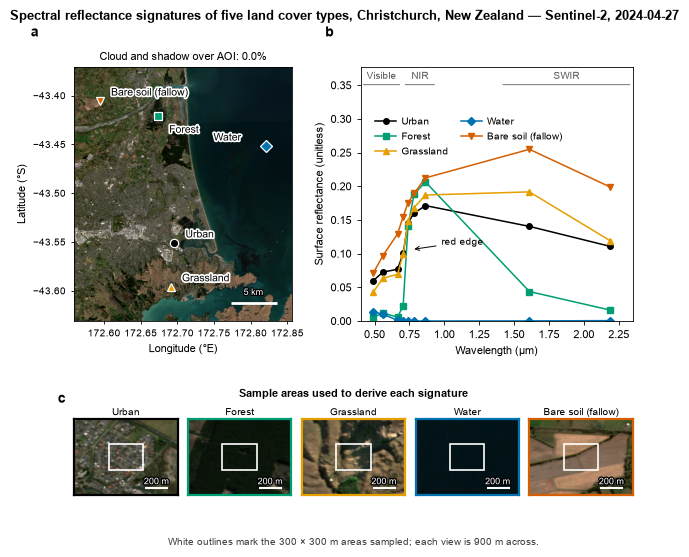


Scene date:      2024-04-27
Cloud over AOI:  0.0%
Dates surveyed:  29  (24 with >=99% AOI coverage)
  Urban                -43.55102, 172.69588
  Forest               -43.42094, 172.67364
  Grassland            -43.59594, 172.69107
  Water                -43.45174, 172.82142
  Bare soil (fallow)   -43.40561, 172.59431


In [41]:
# =====================================================================
# CELL 4 — publication-quality figure
# =====================================================================
import textwrap

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 8, "axes.linewidth": 0.6,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})
MM = 1 / 25.4

LABELS = {"Bare soil": "Bare soil (fallow)"}
lab = lambda c: LABELS.get(c, c)

# --- extract spectra ---------------------------------------------------
fc = ee.FeatureCollection([ee.Feature(g, {"class": k}) for k, g in regions.items()])
spectra_fc = (s2_image.select(BANDS)
              .reduceRegions(collection=fc, reducer=ee.Reducer.mean(), scale=20)
              .getInfo())

spectra = {}
for f in spectra_fc["features"]:
    p = f["properties"]
    if any(p.get(b) is None for b in BANDS):
        raise ValueError(f'"{p["class"]}" has no valid pixels — re-check Cell 3.')
    spectra[p["class"]] = [p[b] * SR_SCALE for b in BANDS]

# --- figure ------------------------------------------------------------
fig = plt.figure(figsize=(183 * MM, 145 * MM))
gs_top = fig.add_gridspec(2, 2, height_ratios=[2.4, 1.15],
                          width_ratios=[1, 1.25], hspace=0.40, wspace=0.28)
gs_bot = fig.add_gridspec(2, 5, height_ratios=[2.4, 1.15], hspace=0.40, wspace=0.10)

# Display extent for panel (a): framed on the samples, not the AOI
_lons = [lon for _, lon in SAMPLES.values()]
_lats = [lat for lat, _ in SAMPLES.values()]
PAD = 0.035
DISPLAY = ee.Geometry.Rectangle([min(_lons) - PAD, min(_lats) - PAD,
                                 max(_lons) + PAD, max(_lats) + PAD])

def add_scalebar(ax, length_m, label, colour="white", pad=0.07, lw=2.0):
    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
    lat_ref = (y0 + y1) / 2
    deg = length_m / (111320 * np.cos(np.radians(lat_ref)))
    xs = x1 - (x1 - x0) * pad - deg
    ys = y0 + (y1 - y0) * pad
    ax.plot([xs, xs + deg], [ys, ys], color=colour, linewidth=lw, solid_capstyle="butt")
    ax.text(xs + deg / 2, ys + (y1 - y0) * 0.025, label, ha="center", va="bottom",
            fontsize=6.5, color=colour,
            path_effects=[pe.withStroke(linewidth=1.8, foreground="black")])

# --- (a) overview map --------------------------------------------------
ax_map = fig.add_subplot(gs_top[0, 0])
xmin, xmax, ymin, ymax = get_bounds_coords(DISPLAY)
ax_map.imshow(fetch_thumb(s2_image_raw, DISPLAY, VIS, dimensions=2400),
              extent=[xmin, xmax, ymin, ymax])
ax_map.set_aspect("auto")

OFFSETS = {"Urban": (8, 4), "Forest": (8, -12), "Grassland": (8, 4),
           "Water": (-38, 4), "Bare soil": (-50, 5)}
for cls in ORDER:
    lat, lon = SAMPLES[cls]
    colour, marker = CLASSES[cls][1], CLASSES[cls][2]
    ax_map.plot(lon, lat, marker=marker, color=colour, markersize=6,
                markeredgecolor="white", markeredgewidth=0.9, linestyle="none")
    ax_map.annotate(lab(cls), (lon, lat), textcoords="offset points",
                    xytext=OFFSETS.get(cls, (8, 4)), fontsize=7.5, color="black",
                    path_effects=[pe.withStroke(linewidth=2.4, foreground="white")])

ax_map.set_xlim(xmin, xmax); ax_map.set_ylim(ymin, ymax)
add_scalebar(ax_map, 5000, "5 km")
ax_map.set_xlabel("Longitude (°E)"); ax_map.set_ylabel("Latitude (°S)")
ax_map.tick_params(direction="out", length=2.5, width=0.6, labelsize=7)
ax_map.set_title(f"Cloud and shadow over AOI: {cloud_pct:.1f}%", fontsize=8, pad=5)
ax_map.text(-0.20, 1.12, "a", transform=ax_map.transAxes,
            fontsize=10, fontweight="bold")

# --- (b) spectral signatures -------------------------------------------
ax = fig.add_subplot(gs_top[0, 1])
for cls in ORDER:
    colour, marker = CLASSES[cls][1], CLASSES[cls][2]
    ax.plot(WAVELENGTH, spectra[cls], marker=marker, markersize=4,
            linewidth=1.1, color=colour, label=lab(cls))

ax.set_xlabel("Wavelength (µm)")
ax.set_ylabel("Surface reflectance (unitless)")
ax.set_xlim(0.40, 2.35)
ax.set_ylim(0, max(max(v) for v in spectra.values()) * 1.48)
ax.tick_params(direction="out", length=3, width=0.6)
ax.grid(False)

top = ax.get_ylim()[1]
for x0, x1, txt in [(0.40, 0.70, "Visible"), (0.70, 0.95, "NIR"), (1.40, 2.35, "SWIR")]:
    ax.annotate("", xy=(x0, top * 0.93), xytext=(x1, top * 0.93),
                arrowprops=dict(arrowstyle="-", linewidth=0.6, color="0.35"))
    ax.text((x0 + x1) / 2, top * 0.945, txt, ha="center", va="bottom",
            fontsize=7, color="0.35", clip_on=False)

ax.legend(frameon=False, fontsize=7.5, ncol=2, loc="upper left",
          bbox_to_anchor=(0.02, 0.84), handletextpad=0.5, columnspacing=1.2)

f_red, f_nir = spectra["Forest"][2], spectra["Forest"][6]
ax.annotate("red edge", xy=(0.765, (f_red + f_nir) / 2),
            xytext=(0.98, top * 0.30), fontsize=7.5, color="black",
            arrowprops=dict(arrowstyle="->", linewidth=0.7, color="black"))
ax.text(-0.13, 1.12, "b", transform=ax.transAxes, fontsize=10, fontweight="bold")

# --- (c) sample area close-ups -----------------------------------------
for i, cls in enumerate(ORDER):
    axc = fig.add_subplot(gs_bot[1, i])
    lat, lon = SAMPLES[cls]
    window = ee.Geometry.Point([lon, lat]).buffer(450).bounds()
    wx0, wx1, wy0, wy1 = get_bounds_coords(window)
    axc.imshow(fetch_thumb(s2_image_raw, window, VIS, dimensions=900),
               extent=[wx0, wx1, wy0, wy1])
    rx0, rx1, ry0, ry1 = get_bounds_coords(regions[cls])
    axc.add_patch(patches.Rectangle((rx0, ry0), rx1 - rx0, ry1 - ry0,
                                    linewidth=1.2, edgecolor="white", facecolor="none"))
    axc.set_xlim(wx0, wx1); axc.set_ylim(wy0, wy1)
    add_scalebar(axc, 200, "200 m", lw=1.5, pad=0.09)
    axc.set_xticks([]); axc.set_yticks([])
    for s in axc.spines.values():
        s.set_linewidth(1.6); s.set_color(CLASSES[cls][1])
    axc.set_title(lab(cls), fontsize=7.5, pad=3)
    if i == 0:
        axc.text(-0.16, 1.22, "c", transform=axc.transAxes,
                 fontsize=10, fontweight="bold")
pos_l = gs_bot[1, 0].get_position(fig)
pos_r = gs_bot[1, 4].get_position(fig)
x_mid = (pos_l.x0 + pos_r.x1) / 2

fig.text(x_mid, pos_l.y1 , "Sample areas used to derive each signature",
         ha="center", va="bottom", fontsize=8, fontweight="bold")
fig.text(x_mid, pos_l.y0 - 0.035,
         "White outlines mark the 300 × 300 m areas sampled; each view is 900 m across.",
         ha="center", va="top", fontsize=7, color="0.25")

fig.suptitle("Spectral reflectance signatures of five land cover types, "
             f"Christchurch, New Zealand — Sentinel-2, {scene_date}",
             fontsize=9.5, fontweight="bold", y=1)
fig.subplots_adjust(top=0.90)

fig.savefig("christchurch_spectra.pdf", bbox_inches="tight")
fig.savefig("christchurch_spectra.png", dpi=600, bbox_inches="tight")
plt.show()

# --- values for the caption -------------------------------------------
print(f"\nScene date:      {scene_date}")
print(f"Cloud over AOI:  {cloud_pct:.1f}%")
print(f"Dates surveyed:  {len(dates)}  ({len(survey)} with >=99% AOI coverage)")
for cls in ORDER:
    print(f"  {lab(cls):<20} {SAMPLES[cls][0]:.5f}, {SAMPLES[cls][1]:.5f}")

In [42]:
cov, cld = scene_quality(s2_image_raw, AOI)
print(f"coverage {cov:.1f}%   cloud {cld:.1f}%")

coverage 100.0%   cloud 0.0%
